In [1]:
import os
import re
import random
import traceback
from datetime import timedelta

import numpy as np
import mne
import gc
import shutil

# ==========================================================================
# 0. CONSTANS AND SEIZURE INFORMATION FUNCTION
# ==========================================================================
CHANNELS_18 = [
    'FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1',
    'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
    'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
    'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2',
    'FZ-CZ',  'CZ-PZ'
]

def select_channels(raw, channel_list):
    rename_dict = {}
    if 'T8-P8-0' in raw.ch_names:
        raw.rename_channels({'T8-P8-0': 'T8-P8'})
    for ch in raw.ch_names:
        clean_name = ch.strip().replace('EEG ', '').upper()
        rename_dict[ch] = clean_name
    raw.rename_channels(rename_dict)

    existing_channels = [ch for ch in channel_list if ch in raw.ch_names]
    print(f'Threre are {len(existing_channels)} channels: ', existing_channels)
    if len(existing_channels) > 0:
        raw.pick(existing_channels)
    return raw


def load_seizures_from_summary(summary_path, edf_filename):
    """Read seizure information (onset, offset) from file summary.txt."""
    seizures = []
    if not os.path.exists(summary_path):
        return seizures

    with open(summary_path, 'r', encoding='latin-1') as f:
        content = f.read()

    file_blocks = content.split('File Name:')
    for block in file_blocks:
        if edf_filename.lower() in block.lower():
            num_seizures_match = re.search(r'Number of Seizures in File:\s*(\d+)', block)
            if not num_seizures_match or int(num_seizures_match.group(1)) == 0:
                return seizures

            onsets = re.findall(r'Seizure\s*(?:\d+)?\s*Start Time:\s*(\d+)\s*seconds', block)
            offsets = re.findall(r'Seizure\s*(?:\d+)?\s*End Time:\s*(\d+)\s*seconds', block)

            for on, off in zip(onsets, offsets):
                seizures.append((float(on), float(off)))
            break

    return seizures

In [2]:
# ==========================================================================
# 1. INTERVAL LENGTHS AND INPUT, OUTPUT PATHs
# ==========================================================================
PREICTAL_SEC          = 30 * 60        # 30 minutes
POSTICTAL_SEC         = 4 * 60 * 60    # 4 hours
INTERICTAL_DIST_SEC   = 4 * 60 * 60    # interictal  must be 4 HOURS away from every onsets and offsets
MIN_SEIZURE_GAP_SEC   = 60 * 60        # two consecutive seizures must be 40 minutes away from each other
CONTINUOUS_TOLERANCE_SEC = 10.0         # two consecutive seizures must be <=10 minutes away from each other

EPOCH_LEN_SEC = 10                     # epoch length

#Kaggle input path
LOCAL_DATA = '/kaggle/input/datasets/abhishekinnvonix/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0'

# output path
SAVE_ROOT  = '/kaggle/working/CHB-MIT_Segment'

In [3]:
# ==========================================================================
# 2. BUILD TIMELINE FOR ONE PATIENT
# ==========================================================================
def _discover_edf_files(subject_dir):
    return sorted([f for f in os.listdir(subject_dir) if f.lower().endswith('.edf')])


def _read_file_infos(subject_dir, subject, edf_files):
    summary_path = os.path.join(subject_dir, f"{subject}-summary.txt")
    file_infos = []
    for f in edf_files:
        raw = mne.io.read_raw_edf(os.path.join(subject_dir, f), preload=False, verbose=False)
        raw = select_channels(raw, CHANNELS_18)

        meas_date = raw.info['meas_date']
        if meas_date is None:
            print(f"[WARN] {f}: No meas_date -> skip this file")
            continue

        duration = raw.times[-1] + (1.0 / raw.info['sfreq'])
        seizures = load_seizures_from_summary(summary_path, f)
        file_infos.append({
            'file': f,
            'raw': raw,
            'start': meas_date,
            'duration': duration,
            'end': meas_date + timedelta(seconds=duration),
            'seizures': seizures,
        })

    file_infos.sort(key=lambda x: x['start'])
    return file_infos


def _group_into_blocks(file_infos):
    if not file_infos:
        return []

    blocks = [[file_infos[0]]]
    for prev, cur in zip(file_infos, file_infos[1:]):
        gap = (cur['start'] - prev['end']).total_seconds()
        if 0 <= gap <= CONTINUOUS_TOLERANCE_SEC:
            blocks[-1].append(cur)
        else:
            blocks.append([cur])
    return blocks


def _concat_block(block_files):
    raws = []
    for fi in block_files:
        raw = fi['raw'].copy()
        raw.load_data()
        raw.notch_filter(freqs=60.0)
        raws.append(raw)
    raw_concat = raws[0] if len(raws) == 1 else mne.concatenate_raws(raws)
    block_start = block_files[0]['start']
    return raw_concat, block_start


def build_timeline(subject_dir, subject):
    edf_files = _discover_edf_files(subject_dir)
    file_infos = _read_file_infos(subject_dir, subject, edf_files)
    grouped = _group_into_blocks(file_infos)

    blocks = []
    for block_files in grouped:
        raw_concat, block_start = _concat_block(block_files)
        blocks.append({
            'raw': raw_concat,
            'start': block_start,
            'duration': raw_concat.times[-1] + (1.0 / raw_concat.info['sfreq']),
            'files': block_files,
        })
    return blocks

In [4]:
# ==========================================================================
# 3. COLLECT EVERY SEIZURES OF A PATIENT AND NUMBERING SEIZURES FOR LOSO EVALUATION (LEAVE-ONE SEIZURE-OUT)
# ==========================================================================
def collect_seizures(blocks):
    all_seizures = []
    for b_idx, block in enumerate(blocks):
        block_start = block['start']
        cum = 0.0
        for finfo in block['files']:
            for (onset, offset) in finfo['seizures']:
                all_seizures.append({
                    'block_idx': b_idx,
                    'onset_in_block': cum + onset,
                    'offset_in_block': cum + offset,
                    'onset_abs': block_start + timedelta(seconds=cum + onset),
                    'offset_abs': block_start + timedelta(seconds=cum + offset),
                })
            cum += finfo['duration']

    all_seizures.sort(key=lambda s: s['onset_abs'])
    for i, s in enumerate(all_seizures):
        s['seizure_id'] = i + 1
    return all_seizures

In [5]:
# ==========================================================================
# 4. GET PREICTAL INTERVAL
# ==========================================================================
def is_preictal_valid(seizure, all_seizures):
    if seizure['onset_in_block'] < PREICTAL_SEC:
        return False

    idx = seizure['seizure_id'] - 1
    if idx > 0:
        prev = all_seizures[idx - 1]
        gap_to_prev = (seizure['onset_abs'] - prev['offset_abs']).total_seconds()
        if gap_to_prev < MIN_SEIZURE_GAP_SEC:
            return False

    return True

def get_seizure_windows(seizure, block, all_seizures):
    onset = seizure['onset_in_block']
    windows = {}

    if is_preictal_valid(seizure, all_seizures):
        windows['preictal'] = (onset - PREICTAL_SEC, onset)
    else:
        windows['preictal'] = None

    return windows

In [6]:
# ==========================================================================
# 5. GET INTERICTAL INTERVAL
# ==========================================================================
def get_interictal_windows(block, all_seizures):
    block_start = block['start']
    block_duration = block['duration']
    block_end = block_start + timedelta(seconds=block_duration)

    excluded = []
    for s in all_seizures:
        excl_start_abs = s['onset_abs'] - timedelta(seconds=INTERICTAL_DIST_SEC)
        excl_end_abs = s['offset_abs'] + timedelta(seconds=INTERICTAL_DIST_SEC)

        seg_start_abs = max(excl_start_abs, block_start)
        seg_end_abs = min(excl_end_abs, block_end)
        if seg_start_abs < seg_end_abs:
            excluded.append((
                (seg_start_abs - block_start).total_seconds(),
                (seg_end_abs - block_start).total_seconds(),
            ))

    excluded.sort()
    merged = []
    for s0, e0 in excluded:
        if merged and s0 <= merged[-1][1]:
            merged[-1] = (merged[-1][0], max(merged[-1][1], e0))
        else:
            merged.append((s0, e0))

    interictal_windows = []
    cursor = 0.0
    for s0, e0 in merged:
        if cursor < s0:
            interictal_windows.append((cursor, s0))
        cursor = max(cursor, e0)
    if cursor < block_duration:
        interictal_windows.append((cursor, block_duration))

    return interictal_windows

In [7]:
# ==========================================================================
# 6. EPOCH AND SAVE
# ==========================================================================
def save_fold_npy(data, label, class_dir):
    os.makedirs(class_dir, exist_ok=True)
    
    free_gb = shutil.disk_usage(class_dir).free / (1024**3)

    print(f"Free disk: {free_gb:.2f} GB")

    np.save(os.path.join(class_dir, f"{label}.npy"), data)
    
def crop_to_epochs(raw, t_start, t_end, epoch_len=EPOCH_LEN_SEC):
    t_end = min(t_end, raw.times[-1])
    if t_end - t_start < epoch_len:
        return None
    cropped = raw.copy().crop(tmin=max(t_start, 0), tmax=t_end, include_tmax=False)
    epochs = mne.make_fixed_length_epochs(cropped, duration=epoch_len, reject_by_annotation=True, preload=True, verbose=False)
    epochs.drop_bad()
    
    if len(epochs) == 0:
        del epochs
        gc.collect()
        return 0
    return epochs

In [8]:
# GET CONTINUOUS WINDOW FOR FAR/H CALCULATION
def get_testing_windows(block, block_idx, blocks, all_seizures):
    sz_in_block = [sz for sz in all_seizures if (sz['block_idx']==block_idx)]
    block_raw = block['raw']
    windows = []
    previous_sz = None
    if len(sz_in_block)>0:
        for idx,sz in enumerate(sz_in_block):
            if idx==0:
                windows.append((0, sz['onset_in_block']))
            elif previous_sz is not None:
                windows.append((previous_sz['offset_in_block'], sz['onset_in_block']))
            previous_sz = sz
        windows.append((sz['offset_in_block'], block_raw.times[-1] + (1/block_raw.info['sfreq'])))  
        
        return sz_in_block, windows
    else:
        return sz_in_block, [(0, block_raw.times[-1] + (1/block_raw.info['sfreq']))]

In [9]:
# ==========================================================================
# 7. PROCESSING PIPELINE FOR ONE PATIENT 
# ==========================================================================
def process_subject(subject):
    subject_dir = os.path.join(LOCAL_DATA, subject)
    save_dir = os.path.join(SAVE_ROOT, subject)

    print(f"\n--- PROCESSING: {subject.upper()} ---")
    blocks = build_timeline(subject_dir, subject)
    all_seizures = collect_seizures(blocks)

    if len(all_seizures) == 0:
        print(f"{subject}: No seizure, skip")
        return

    print(f"{subject}: Total {len(all_seizures)} seizures (1..{len(all_seizures)})")

    # ---- PHASE 1: GET PREICTAL EPOCHS ----
    print('PHASE 1')
    training_dir = os.path.join(save_dir, 'Training')
    class_dir = os.path.join(training_dir, 'preictal')

    for s in all_seizures:
        block = blocks[s['block_idx']]
        raw = block['raw']
        windows = get_seizure_windows(s, block, all_seizures)
        sid = s['seizure_id']

        win = windows['preictal']
        if win is None:
            print(f"  Seizure number {sid:02d}: does not contain enough preictal data (skip this seizure)")
            continue

        epochs = crop_to_epochs(raw, win[0], win[1])
        epochs.get_data()
        save_fold_npy(epochs, sid, class_dir)
        del epochs
        print(f"  Seizure number {sid:02d}: Preictal OK")


    # ---- PHASE 2: GET INTERICTAL EPOCHS ----
    print('PHASE 2')
    class_dir = os.path.join(training_dir, 'interictal')
    batch_idx = 0
    batch_size = 1800
    for block_idx, block in enumerate(blocks):
        print(f"Block: {block_idx} tu {block['files'][0]['file']} den {block['files'][-1]['file']}")
        print(f"Block duration: {block['duration']}")
        for (w0, w1) in get_interictal_windows(block, all_seizures):
            epochs = crop_to_epochs(block['raw'], w0, w1)
            if epochs is not None and len(epochs) > 0:
                for i in range(0, len(epochs), batch_size):
                    print(f"Patient: {subject}")
                    print(f"Epochs: {len(epochs)}")
                    print(f"Shape: {epochs.get_data(copy=False).shape}")
                    print(f"Batch: {i}:{min(i + batch_size, len(epochs))}")
                    batch = epochs[i:i + batch_size].get_data(copy=False)
                    save_fold_npy(batch, batch_idx, class_dir)
                    batch_idx += 1
                    del batch
            del epochs
                
            print(f'Get {w1-w0}s interictal interval')
    
    
    # ---- PHASE 3: SEGMENT CONTINUOUS DATA TO CALCULATE FAR/H ----
    print('PHASE 3')
    testing_dir = os.path.join(save_dir, 'testing')
    previous_epochs = None
    batch_size = 1800
    for block_idx, block in enumerate(blocks):
        print(f"Block: {block_idx} from {block['files'][0]['file']} to {block['files'][-1]['file']}")
        raw = block['raw']
        sz_in_block, windows = get_testing_windows(block, block_idx, blocks, all_seizures)
        if len(sz_in_block)>0:
            for (idx, sz), window in zip(enumerate(sz_in_block), windows[:len(windows)-1]):
                sid = sz['seizure_id']
                print('seizure ID: ', sid)
                testing_dir_sz = os.path.join(testing_dir, str(sid))
                epochs = crop_to_epochs(raw, window[0], window[1])
                if idx==0 and previous_epochs is not None:
                    epochs = mne.concatenate_epochs([previous_epochs.copy(), epochs])
                    del previous_epochs
                if epochs is not None:
                    batch_idx = 0
                    print(f'Epoch size: {len(epochs)}')
                    for i in range(0, len(epochs), batch_size):
                        print(f"Batch: {i}:{min(i + batch_size, len(epochs))}")
                        batch = epochs[i:i + batch_size].get_data(copy=False)
                        save_fold_npy(batch, batch_idx, testing_dir_sz)
                        batch_idx += 1
                        del batch
                    del epochs
            previous_epochs = crop_to_epochs(raw, windows[-1][0], windows[-1][1])
        else: 
            temp = crop_to_epochs(raw, windows[-1][0], windows[-1][1])
            if previous_epochs!=None:
                previous_epochs = mne.concatenate_epochs([previous_epochs, temp])
            else:
                previous_epochs = temp

In [10]:
# ==========================================================================
# 8. PROCESSING FOR EVERY PATIENTS
# ==========================================================================
def discover_subjects(local_data):
    pattern = re.compile(r'^chb\d{2}$')
    return sorted([d for d in os.listdir(local_data)
                   if pattern.match(d) and os.path.isdir(os.path.join(local_data, d))])

if __name__ == '__main__':
    subjects = discover_subjects(LOCAL_DATA)
    print(f"Discover {len(subjects)} patients: {subjects}")
    for subject in subjects:
        try:
            process_subject(subject)
        except Exception as e:
            print(f"[ERROR] {subject}: {e}")
            traceback.print_exc()

Discover 24 patients: ['chb01', 'chb02', 'chb03', 'chb04', 'chb05', 'chb06', 'chb07', 'chb08', 'chb09', 'chb10', 'chb11', 'chb12', 'chb13', 'chb14', 'chb15', 'chb16', 'chb17', 'chb18', 'chb19', 'chb20', 'chb21', 'chb22', 'chb23', 'chb24']

--- PROCESSING: CHB01 ---


/tmp/ipykernel_58/2341922849.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(subject_dir, f), preload=False, verbose=False)


Threre are 18 channels:  ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ']


/tmp/ipykernel_58/2341922849.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(subject_dir, f), preload=False, verbose=False)
/tmp/ipykernel_58/2341922849.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(subject_dir, f), preload=False, verbose=False)
/tmp/ipykernel_58/2341922849.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(subject_dir, f), preload=False, verbose=False)
/tmp/ipykernel_58/2341922849.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(subject_dir, f), preload=False, verbose=False)
/tmp/ipykernel_58/234192

Threre are 18 channels:  ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ']
Threre are 18 channels:  ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ']
Threre are 18 channels:  ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ']
Threre are 18 channels:  ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ']
Threre are 18 channels:  ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ']


...

/tmp/ipykernel_58/2341922849.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(subject_dir, f), preload=False, verbose=False)
/tmp/ipykernel_58/2341922849.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(subject_dir, f), preload=False, verbose=False)
/tmp/ipykernel_58/2341922849.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(subject_dir, f), preload=False, verbose=False)
/tmp/ipykernel_58/2341922849.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(subject_dir, f), preload=False, verbose=False)
/tmp/ipykernel_58/234192

Threre are 18 channels:  ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ']
Threre are 18 channels:  ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ']
Threre are 18 channels:  ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ']
Threre are 18 channels:  ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ']
Threre are 18 channels:  ['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ']
Threre are 18 channels:  ['FP1-F7', 'F7-

/tmp/ipykernel_58/2341922849.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(subject_dir, f), preload=False, verbose=False)
/tmp/ipykernel_58/2341922849.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(subject_dir, f), preload=False, verbose=False)
/tmp/ipykernel_58/2341922849.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(subject_dir, f), preload=False, verbose=False)
/tmp/ipykernel_58/2341922849.py:12: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(os.path.join(subject_dir, f), preload=False, verbose=False)
/tmp/ipykernel_58/234192

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1691 samples (6.605 s)

Reading 0 ... 921599  =      0.000 ...  3599.996 secs...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50

KeyboardInterrupt: 

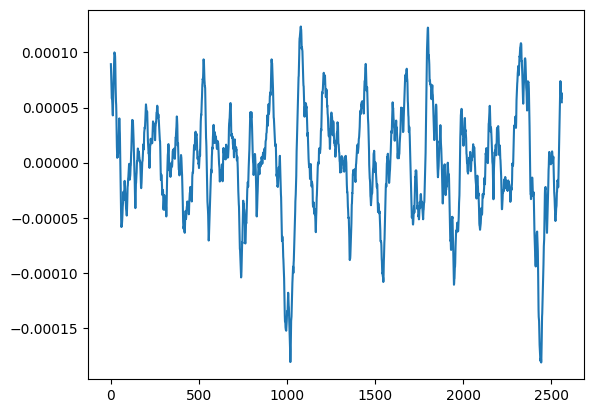

In [11]:
nm = np.load('/kaggle/working/CHB-MIT_Segment/chb01/Training/preictal/1.npy')
import matplotlib.pyplot as plt
plt.plot(nm[0][0])